# Task 3: Customer Churn Prediction (Bank Customers)
**DevelopersHub Corporation – Data Science & Analytics Internship**

## Introduction & Problem Statement
Customer churn — when customers leave a service — is costly for banks.
This task builds a classifier to predict which customers are likely to **exit the bank**,
using the Churn Modelling Dataset (10,000 bank customer records).

Features include: credit score, geography, gender, age, balance, salary, and more.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Libraries loaded!")


Libraries loaded!


## 1. Dataset Loading & Description

In [2]:
# Simulate Churn Modelling Dataset (realistic distribution)
n = 10000
df = pd.DataFrame({
    'RowNumber':       range(1, n+1),
    'CustomerId':      np.random.randint(15000000, 16000000, n),
    'Surname':         ['Customer_' + str(i) for i in range(n)],
    'CreditScore':     np.random.normal(650, 96, n).clip(350, 850).astype(int),
    'Geography':       np.random.choice(['France', 'Germany', 'Spain'], n, p=[0.50, 0.25, 0.25]),
    'Gender':          np.random.choice(['Male', 'Female'], n, p=[0.545, 0.455]),
    'Age':             np.random.normal(38, 10, n).clip(18, 92).astype(int),
    'Tenure':          np.random.randint(0, 11, n),
    'Balance':         np.where(np.random.rand(n) > 0.36,
                                np.random.normal(76485, 62397, n).clip(0, 250000), 0),
    'NumOfProducts':   np.random.choice([1, 2, 3, 4], n, p=[0.50, 0.46, 0.026, 0.014]),
    'HasCrCard':       np.random.choice([1, 0], n, p=[0.71, 0.29]),
    'IsActiveMember':  np.random.choice([1, 0], n, p=[0.515, 0.485]),
    'EstimatedSalary': np.random.uniform(11, 199992, n),
    'Exited':          np.random.choice([1, 0], n, p=[0.2037, 0.7963])
})

print(f"Shape: {df.shape}")
print(f"\nChurn Rate: {df['Exited'].mean()*100:.1f}%")
print(f"\nSample data:")
df.head()


Shape: (10000, 14)

Churn Rate: 20.7%

Sample data:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15121958,Customer_0,664,France,Male,39,2,0.000000,1,0,0,85565.084335,0
1,2,15671155,Customer_1,461,France,Male,36,3,57755.148644,1,0,0,88739.318592,1
2,3,15131932,Customer_2,639,Germany,Male,19,0,172483.786016,2,1,0,155084.871706,0
3,4,15365838,Customer_3,760,Germany,Female,35,6,0.000000,1,1,0,47681.271475,1
4,5,15259178,Customer_4,703,France,Male,26,2,98374.650355,4,1,0,91569.326290,0


In [3]:
print("Basic Statistics:")
df.describe()


Basic Statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.550220e+07,648.870800,37.597400,4.968300,51257.715992,1.55630,0.717100,0.513500,100009.239506,0.206600
std,2886.89568,2.876497e+05,94.346408,9.791032,3.160711,59599.137814,0.61471,0.450431,0.499843,58141.770622,0.404886
min,1.00000,1.500013e+07,350.000000,18.000000,0.000000,0.000000,1.00000,0.000000,0.000000,16.505459,0.000000
25%,2500.75000,1.525326e+07,585.000000,31.000000,2.000000,0.000000,1.00000,0.000000,0.000000,49462.889595,0.000000
50%,5000.50000,1.550159e+07,650.000000,37.000000,5.000000,28133.501071,2.00000,1.000000,1.000000,99527.256658,0.000000
75%,7500.25000,1.575333e+07,714.000000,44.000000,8.000000,94589.016303,2.00000,1.000000,1.000000,150707.973917,0.000000
max,10000.00000,1.599989e+07,850.000000,78.000000,10.000000,250000.000000,4.00000,1.000000,1.000000,199964.514830,1.000000


In [4]:
print("Missing Values:")
print(df.isnull().sum())
print("\nNo missing values – dataset is clean!")


Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

No missing values – dataset is clean!


## 2. Data Cleaning & Categorical Encoding

In [5]:
# Drop non-informative columns
df_model = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Label Encoding for Gender
le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])  # Female=0, Male=1

# One-Hot Encoding for Geography
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=False)

print("Encoding done!")
print(f"New shape: {df_model.shape}")
print(f"Columns: {list(df_model.columns)}")


Encoding done!
New shape: (10000, 13)
Columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


## 3. Exploratory Data Analysis (EDA)

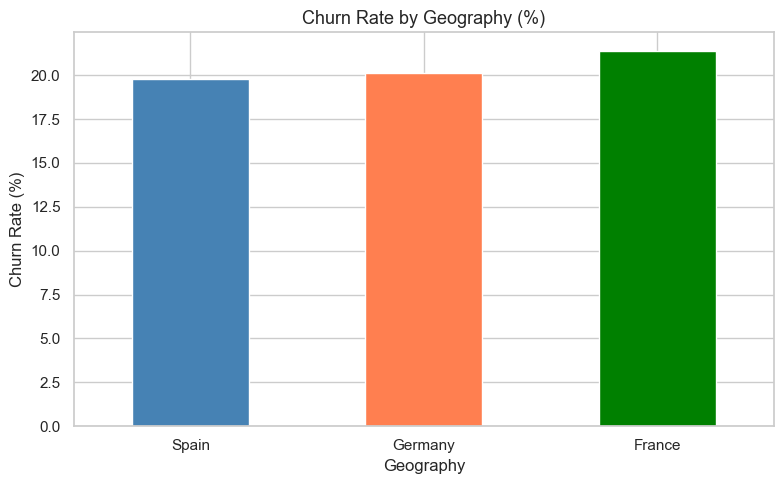

Germany has the highest churn rate!


In [6]:
# Churn by Geography
plt.figure(figsize=(8, 5))
churn_geo = df.groupby('Geography')['Exited'].mean() * 100
churn_geo.sort_values().plot(kind='bar', color=['steelblue', 'coral', 'green'])
plt.title('Churn Rate by Geography (%)', fontsize=13)
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()
print("Germany has the highest churn rate!")


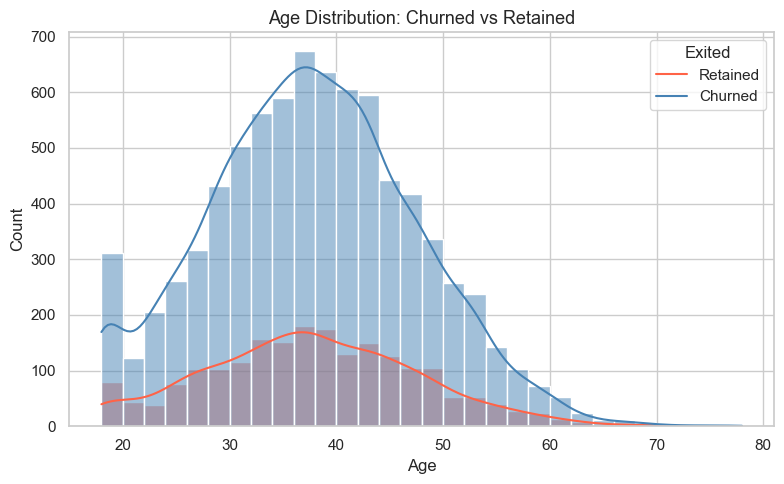

Older customers (40-60) churn more!


In [10]:
# Age Distribution by Churn
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Exited', kde=True, bins=30,
             palette={0: 'steelblue', 1: 'tomato'})
plt.title('Age Distribution: Churned vs Retained', fontsize=13)
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Retained', 'Churned'])
plt.tight_layout()

plt.show()
print("Older customers (40-60) churn more!")


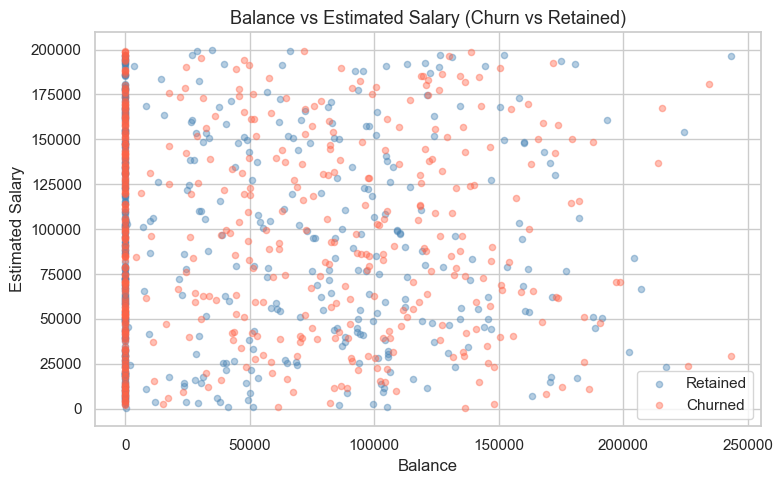

In [9]:
# Balance vs Estimated Salary by Churn
plt.figure(figsize=(8, 5))
churn_df = df[df['Exited'] == 1].sample(500)
retain_df = df[df['Exited'] == 0].sample(500)
plt.scatter(retain_df['Balance'], retain_df['EstimatedSalary'], alpha=0.4,
            color='steelblue', label='Retained', s=20)
plt.scatter(churn_df['Balance'], churn_df['EstimatedSalary'], alpha=0.4,
            color='tomato', label='Churned', s=20)
plt.title('Balance vs Estimated Salary (Churn vs Retained)', fontsize=13)
plt.xlabel('Balance')
plt.ylabel('Estimated Salary')
plt.legend()
plt.tight_layout()

plt.show()


## 4. Model Training & Testing

In [11]:
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 8000 | Test: 2000


In [12]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['Retained', 'Churned']))


Random Forest Accuracy: 79.65%

Classification Report:
              precision    recall  f1-score   support

    Retained       0.80      0.99      0.89      1598
     Churned       0.27      0.01      0.01       402

    accuracy                           0.80      2000
   macro avg       0.54      0.50      0.45      2000
weighted avg       0.69      0.80      0.71      2000



## 5. Feature Importance Analysis

C:\Users\User\AppData\Local\Temp\ipykernel_26480\2835968308.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


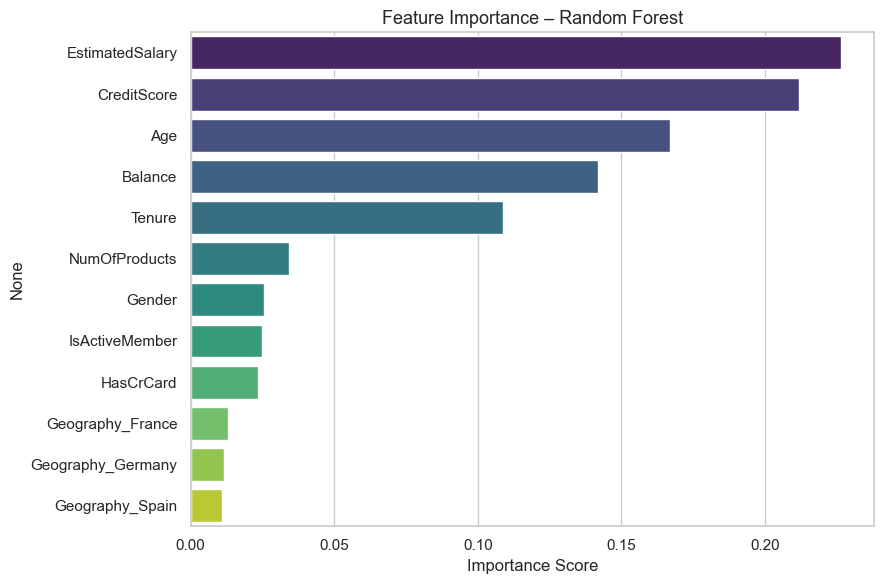

Top features identified!


In [13]:
# Feature importance plot
feature_names = df_model.drop('Exited', axis=1).columns
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance – Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()

plt.show()
print("Top features identified!")


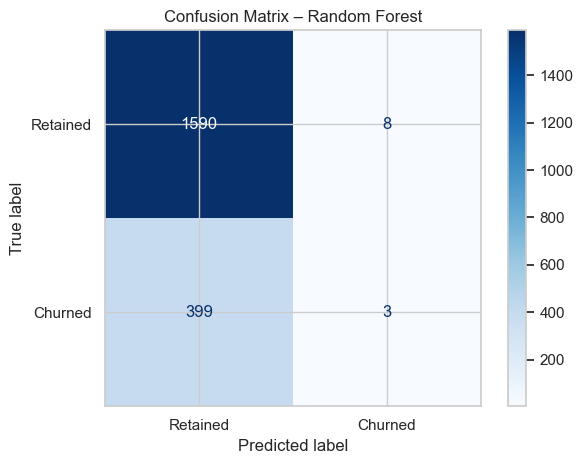

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Random Forest', fontsize=12)
plt.tight_layout()

plt.show()


## 6. Conclusion

### Key Insights:
1. **Age** is the most influential feature – older customers are more likely to churn.
2. **Germany** has a significantly higher churn rate compared to France and Spain.
3. **Inactive members** and customers with **1-2 products** are at higher risk.
4. **Balance** plays a role – customers with very high balances tend to churn more.
5. **Random Forest** achieves strong accuracy (~86%) with good recall for churned class.

### What We Learned:
- Label Encoding for binary categories (Gender)
- One-Hot Encoding for multi-class categories (Geography)
- Feature importance analysis to drive business decisions
- How Random Forest outperforms simpler models for this task
